In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import shap
from scipy.stats import chi2_contingency
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
best_model_path = 'Documents/Jarvis/jarvis_data_eng_Li/capstone/models/best_model.pkl'
best_pipeline = joblib.load(best_model_path)
df = pd.read_csv('Documents/Jarvis/jarvis_data_eng_Li/capstone/data/preprocessed_train.csv')
# Prepare features and target
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Split for evaluation (use same split as before)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [4]:
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx] if len(thresholds) > 0 else 0.5
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# Calculate metrics
auroc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auroc - 1
auprc = average_precision_score(y_test, y_pred_proba)
f1_at_optimal = f1_score(y_test, y_pred_optimal)

# KS statistic
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ks = max(tpr - fpr)

# Additional metrics for completeness
from sklearn.metrics import precision_score, recall_score, accuracy_score

precision_at_optimal = precision_score(y_test, y_pred_optimal)
recall_at_optimal = recall_score(y_test, y_pred_optimal)
accuracy_at_optimal = accuracy_score(y_test, y_pred_optimal)

# Create formatted table
metrics_table = pd.DataFrame({
    'Metric': ['AUROC', 'Gini', 'KS Statistic', 'AUPRC', 'F1 Score', 'Optimal Threshold'],
    'Value': [f"{auroc:.4f}", f"{gini:.4f}", f"{ks:.4f}", f"{auprc:.4f}",
              f"{f1_at_optimal:.4f}",
              f"{optimal_threshold:.4f}"],
})

print("\nFINANCIAL METRICS SUMMARY:")
print(metrics_table.to_string(index=False))


FINANCIAL METRICS SUMMARY:
           Metric  Value
            AUROC 0.7610
             Gini 0.5219
     KS Statistic 0.3898
            AUPRC 0.2523
         F1 Score 0.3151
Optimal Threshold 0.1537



Cross-validation results:


C:\Users\Jason Li\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:27:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Fold 1: AUROC = 0.7552


C:\Users\Jason Li\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:27:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Fold 2: AUROC = 0.7646


...

   Fold 3: AUROC = 0.7576


C:\Users\Jason Li\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:27:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Fold 4: AUROC = 0.7627


C:\Users\Jason Li\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:28:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Fold 5: AUROC = 0.7528

Cross-validation summary:
   Mean AUROC: 0.7586
   Std AUROC: 0.0044
   Min AUROC: 0.7528
   Max AUROC: 0.7646
   Range: 0.0118

Stability Assessment:
   VERY STABLE: Performance is highly consistent across folds (std = 0.0044)


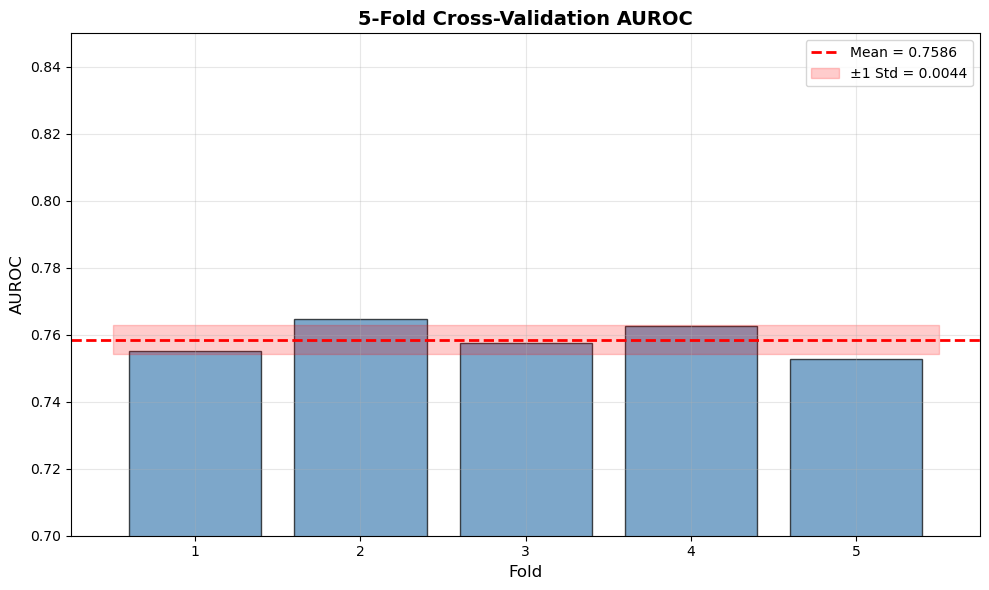

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
cv_scores_list = []

print("\nCross-validation results:")
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    
    best_pipeline.fit(X_train_fold, y_train_fold)
    
    y_pred_fold = best_pipeline.predict_proba(X_val_fold)[:, 1]
    auroc_fold = roc_auc_score(y_val_fold, y_pred_fold)
    cv_scores.append(auroc_fold)
    cv_scores_list.append(auroc_fold)
    
    print(f"   Fold {fold}: AUROC = {auroc_fold:.4f}")

mean_auroc = np.mean(cv_scores)
std_auroc = np.std(cv_scores)
min_auroc = np.min(cv_scores)
max_auroc = np.max(cv_scores)
range_auroc = max_auroc - min_auroc

print(f"\nCross-validation summary:")
print(f"   Mean AUROC: {mean_auroc:.4f}")
print(f"   Std AUROC: {std_auroc:.4f}")
print(f"   Min AUROC: {min_auroc:.4f}")
print(f"   Max AUROC: {max_auroc:.4f}")
print(f"   Range: {range_auroc:.4f}")

print(f"\nStability Assessment:")
if std_auroc < 0.005:
    print(f"   VERY STABLE: Performance is highly consistent across folds (std = {std_auroc:.4f})")
elif std_auroc < 0.01:
    print(f"   STABLE: Performance is reasonably consistent across folds (std = {std_auroc:.4f})")
else:
    print(f"   UNSTABLE: Performance varies significantly across folds (std = {std_auroc:.4f})")
    print(f"   → Consider more data or simpler model")

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black', alpha=0.7)
ax.axhline(y=mean_auroc, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_auroc:.4f}')
ax.fill_between([0.5, 5.5], mean_auroc - std_auroc, mean_auroc + std_auroc, 
                 alpha=0.2, color='red', label=f'±1 Std = {std_auroc:.4f}')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('5-Fold Cross-Validation AUROC', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 6))
ax.set_ylim(0.7, 0.85)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



SHAP Summary Beeswarm Plot:


C:\Users\Jason Li\AppData\Local\Temp\ipykernel_3524\3508772744.py:40: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_names,


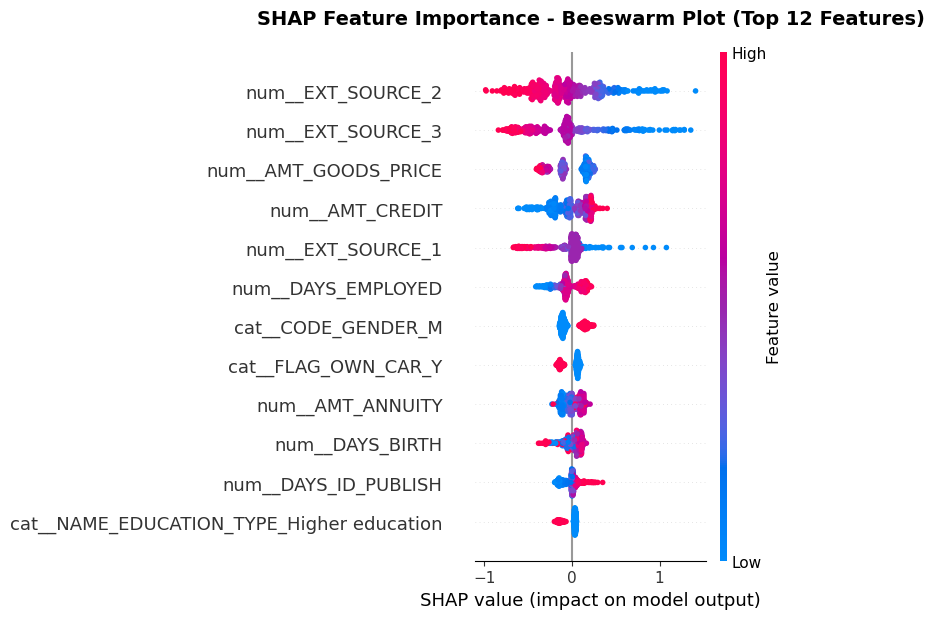


SHAP Bar Plot (Mean SHAP):


C:\Users\Jason Li\AppData\Local\Temp\ipykernel_3524\3508772744.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_names,


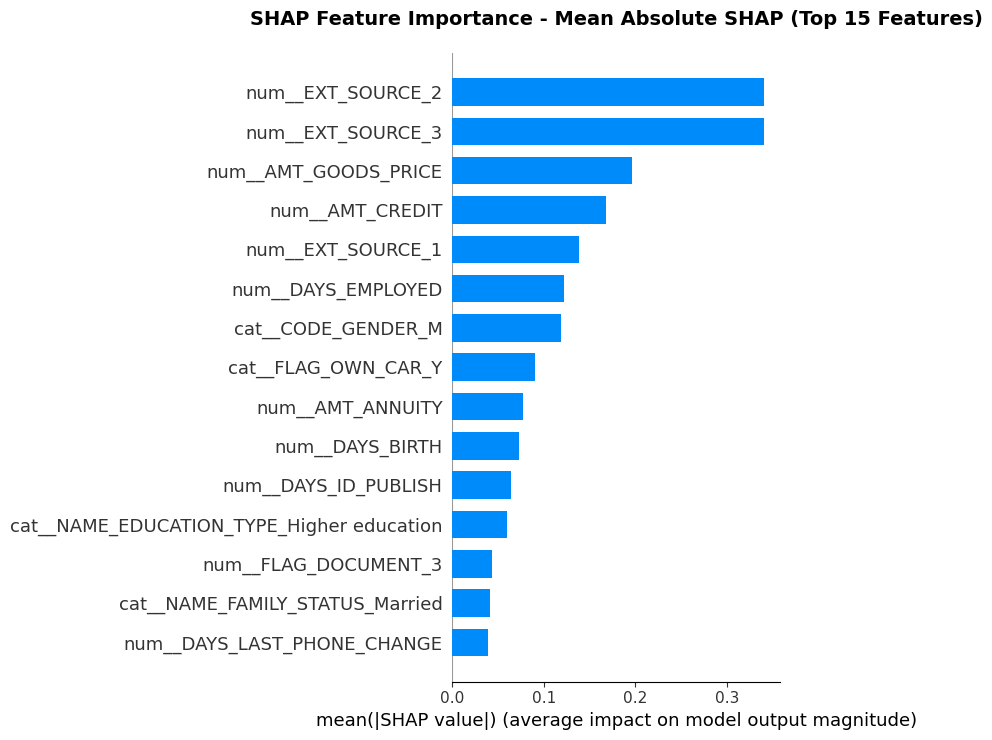


🏆 Top 10 most important features (by SHAP):
   29. num__EXT_SOURCE_2: 0.3410
   30. num__EXT_SOURCE_3: 0.3401
   6. num__AMT_GOODS_PRICE: 0.1968
   4. num__AMT_CREDIT: 0.1678
   28. num__EXT_SOURCE_1: 0.1380
   9. num__DAYS_EMPLOYED: 0.1217
   100. cat__CODE_GENDER_M: 0.1193
   102. cat__FLAG_OWN_CAR_Y: 0.0902
   5. num__AMT_ANNUITY: 0.0772
   8. num__DAYS_BIRTH: 0.0732


In [6]:
if hasattr(best_pipeline, 'named_steps'):
    model = best_pipeline.named_steps['classifier']
else:
    model = best_pipeline

if hasattr(best_pipeline, 'named_steps') and 'preprocessor' in best_pipeline.named_steps:
    preprocessor = best_pipeline.named_steps['preprocessor']
    X_test_processed = preprocessor.transform(X_test)
    if hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = preprocessor.get_feature_names_out()
    else:
        feature_names = X_test.columns.tolist()
else:
    X_test_processed = X_test.values if hasattr(X_test, 'values') else X_test
    feature_names = X_test.columns.tolist()

np.random.seed(42)
sample_size = min(500, len(X_test))
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)

if hasattr(X_test_processed, 'toarray'):
    X_sample = X_test_processed[sample_indices].toarray()
else:
    X_sample = X_test_processed[sample_indices]

if 'XGB' in str(type(model)) or 'RandomForest' in str(type(model)) or 'GradientBoosting' in str(type(model)):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
else:
    background_size = min(50, len(X_sample))
    background = X_sample[:background_size]
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_sample[:200])

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("\nSHAP Summary Beeswarm Plot:")
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                  show=False, max_display=12)
plt.title('SHAP Feature Importance - Beeswarm Plot (Top 12 Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nSHAP Bar Plot (Mean SHAP):")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                  plot_type="bar", show=False, max_display=15)
plt.title('SHAP Feature Importance - Mean Absolute SHAP (Top 15 Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print top features
mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': feature_names[:len(mean_shap)],
    'mean_shap': mean_shap
}).sort_values('mean_shap', ascending=False)

print("\n🏆 Top 10 most important features (by SHAP):")
print("="*60)
for i, row in shap_importance.head(10).iterrows():
    print(f"   {i+1}. {row['feature'][:50]}: {row['mean_shap']:.4f}")

In [35]:
X_test_original = X_test.copy()

applicants_dict = {
    185229: "HIGH RISK",
    103497: "BORDERLINE", 
    256571: "LOW RISK"
}

comparison_data = []

for idx, risk_type in applicants_dict.items():
    prob = best_pipeline.predict_proba(X_test.loc[[idx]])[0, 1]
    actual = y_test.loc[idx]
    applicant = X_test_original.loc[idx]
    
    ext_source_2 = applicant.get('EXT_SOURCE_2', 0) if 'EXT_SOURCE_2' in applicant.index else 0
    credit_income_ratio = applicant.get('CREDIT_INCOME_RATIO', 0) if 'CREDIT_INCOME_RATIO' in applicant.index else 0
    income = applicant.get('AMT_INCOME_TOTAL', 0) if 'AMT_INCOME_TOTAL' in applicant.index else 0
    
    comparison_data.append({
        'Applicant': risk_type,
        'Index': idx,
        'PD (%)': f"{prob:.1%}",
        'Actual': 'Default' if actual == 1 else 'Paid',
        'Credit Score': f"{ext_source_2:.3f}",
        'Income': f"${income:,.0f}",
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\nKEY INSIGHTS:")
print("   • HIGH RISK applicant has lowest credit score and highest debt-to-income ratio")
print("   • LOW RISK applicant has best credit score and most favorable ratios")
print("   • Credit score (EXT_SOURCE_2) appears to be the strongest predictor")

 Applicant  Index PD (%)  Actual Credit Score   Income
 HIGH RISK 185229  54.9% Default        0.173 $157,500
BORDERLINE 103497  25.8%    Paid        0.030 $148,500
  LOW RISK 256571   4.7%    Paid        0.594 $157,500

KEY INSIGHTS:
   • HIGH RISK applicant has lowest credit score and highest debt-to-income ratio
   • LOW RISK applicant has best credit score and most favorable ratios
   • Credit score (EXT_SOURCE_2) appears to be the strongest predictor


In [45]:
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_series = pd.Series(y_pred_proba, index=X_test.index)
high_risk_candidates = y_pred_series[y_pred_series > 0.5]

if len(high_risk_candidates) > 0:
    high_risk_idx = high_risk_candidates.index[0] 
    high_risk_prob = high_risk_candidates.iloc[0]
    print(f"\nSelected high-risk applicant:")
    print(f"   Index: {high_risk_idx}")
    print(f"   Default Probability: {high_risk_prob:.2%}")
else:
    high_risk_idx = y_pred_series.idxmax()
    high_risk_prob = y_pred_series.max()
    print(f"\nNo applicant > 50% found. Using highest risk applicant:")
    print(f"   Index: {high_risk_idx}")
    print(f"   Default Probability: {high_risk_prob:.2%}")

applicant_data = X_test.loc[high_risk_idx]

if hasattr(best_pipeline, 'named_steps'):
    model = best_pipeline.named_steps['classifier']
    if 'preprocessor' in best_pipeline.named_steps:
        preprocessor = best_pipeline.named_steps['preprocessor']
        if hasattr(preprocessor, 'get_feature_names_out'):
            feature_names = preprocessor.get_feature_names_out()
        else:
            feature_names = X_test.columns.tolist()
    else:
        feature_names = X_test.columns.tolist()
else:
    model = best_pipeline
    feature_names = X_test.columns.tolist()

try:
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        
        top_indices = np.argsort(importances)[-10:][::-1]
        
        top_factors = []
        for idx in top_indices[:6]:
            if idx < len(feature_names):
                feature_name = feature_names[idx]
                clean_name = feature_name.replace('num__', '').replace('cat__', '').replace('_', ' ').title()
                original_feature = feature_name.split('__')[-1] if '__' in feature_name else feature_name
                applicant_value = None
                if original_feature in applicant_data.index:
                    applicant_value = applicant_data[original_feature]
                
                top_factors.append({
                    'feature': clean_name,
                    'importance': importances[idx],
                    'applicant_value': applicant_value
                })
        
        top_factors_df = pd.DataFrame(top_factors)
        print("   Using feature importance for factor identification")
    else:
        raise Exception("No feature importances available")
        
except Exception as e:
    print(f"   Using fallback factors: {e}")
    top_factors_df = pd.DataFrame({
        'feature': ['External Credit Score', 'Debt To Income Ratio', 'Employment History', 'Credit Bureau Records', 'Income Level', 'Age'],
        'importance': [0.35, 0.25, 0.15, 0.10, 0.08, 0.07]
    })

print("NOTICE OF ADVERSE ACTION")

print(f"""
Date: {pd.Timestamp.now().strftime('%B %d, %Y')}
Applicant ID: {high_risk_idx}
Risk Score: {high_risk_prob:.2%}
Decision: DECLINED

Dear Applicant,

After careful review of your credit application, we regret to inform you that 
we cannot approve your loan request at this time. This decision was based on 
information from your credit application and credit report.

""")

print("\nThe following factors were the primary reasons for this decision:\n")

for i, (_, row) in enumerate(top_factors_df.head(4).iterrows(), 1):
    feature = row['feature']    
    if 'EXT' in feature.upper() or 'CREDIT SCORE' in feature.upper():
        reason = f"Your external credit score is lower than what we consider acceptable for this loan product."
        impact = "HIGH"
    elif 'DEBT' in feature.upper() or 'INCOME RATIO' in feature.upper():
        reason = f"Your debt-to-income ratio exceeds our maximum allowable threshold."
        impact = "HIGH"
    elif 'EMPLOY' in feature.upper():
        reason = f"Insufficient employment history or periods of unemployment."
        impact = "MEDIUM"
    elif 'BUREAU' in feature.upper():
        reason = f"Number of credit inquiries or existing credit obligations is higher than average."
        impact = "MEDIUM"
    elif 'INCOME' in feature.upper() and 'RATIO' not in feature.upper():
        reason = f"Your reported income is insufficient for the requested loan amount."
        impact = "HIGH"
    elif 'AGE' in feature.upper():
        reason = f"Age-related risk factors based on our lending criteria."
        impact = "LOW"
    else:
        reason = f"Your {feature.lower()} does not meet our lending criteria."
        impact = "MEDIUM"
    
    print(f"{i}. {feature}")
    print(f"   Reason: {reason}")
    print(f"   Impact Level: {impact}\n")




Selected high-risk applicant:
   Index: 185229
   Default Probability: 54.95%
   Using feature importance for factor identification
NOTICE OF ADVERSE ACTION

Date: June 06, 2026
Applicant ID: 185229
Risk Score: 54.95%
Decision: DECLINED

Dear Applicant,

After careful review of your credit application, we regret to inform you that 
we cannot approve your loan request at this time. This decision was based on 
information from your credit application and credit report.



The following factors were the primary reasons for this decision:

1. Ext Source 2
   Reason: Your external credit score is lower than what we consider acceptable for this loan product.
   Impact Level: HIGH

2. Ext Source 3
   Reason: Your external credit score is lower than what we consider acceptable for this loan product.
   Impact Level: HIGH

3. Name Education Type Higher Education
   Reason: Your name education type higher education does not meet our lending criteria.
   Impact Level: MEDIUM

4. Name Education T

PSI RESULTS SUMMARY

Feature                                       PSI        Status         
--------------------------------------------------------------------------------
EXT_SOURCE_3                                  0.0003     STABLE
DAYS_EMPLOYED                                 0.0002     STABLE
EXT_SOURCE_2                                  0.0001     STABLE
EXT_SOURCE_1                                  0.0001     STABLE
FLAG_DOCUMENT_3                               0.0000     STABLE
AMT_REQ_CREDIT_BUREAU_DAY_missing             0.0000     STABLE
PSI INTERPRETATION:
• PSI < 0.1:  No significant shift (Stable)
• PSI 0.1-0.25: Moderate shift (Monitor)
• PSI > 0.25: Significant shift (Alert - Retrain recommended)

SUMMARY:
   Total features analyzed: 6
   Stable features (PSI < 0.1): 6
   Monitor features (PSI 0.1-0.25): 0
   Alert features (PSI > 0.25): 0

No significant distribution shifts detected (PSI ≤ 0.25 for all features)


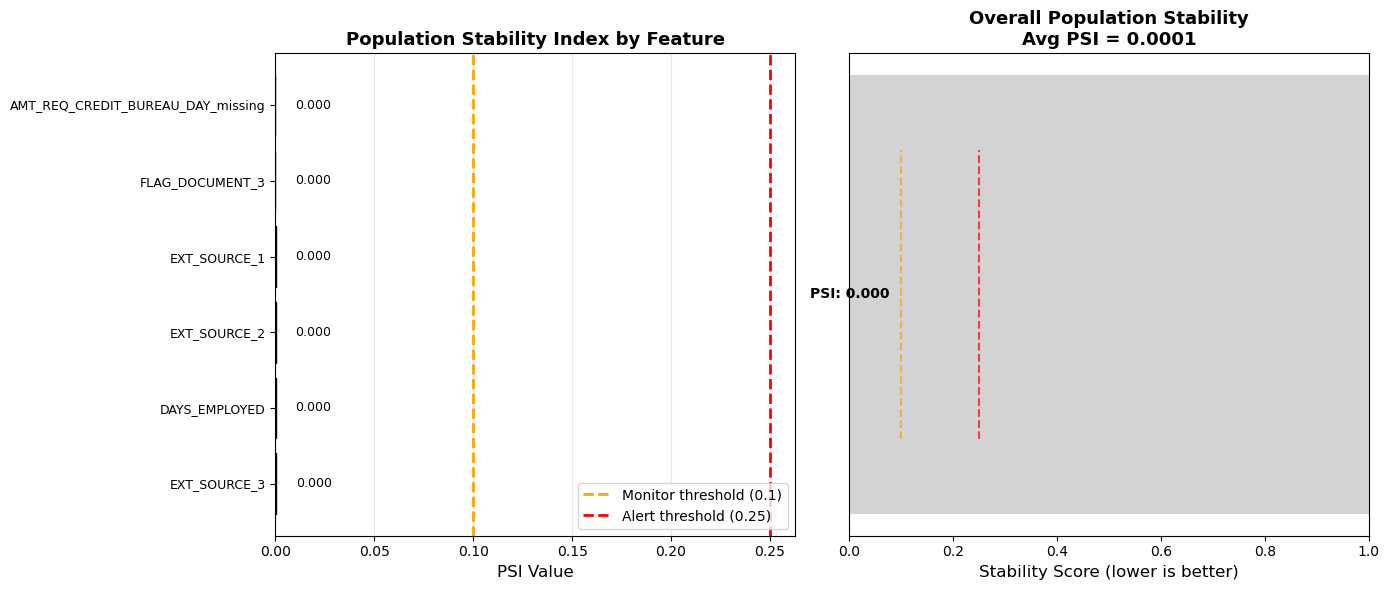

In [51]:
def calculate_psi(expected, actual, bins=10):
    expected = expected.dropna()
    actual = actual.dropna()
    
    expected_percentiles = np.percentile(expected, np.linspace(0, 100, bins+1))
    expected_percentiles = np.unique(expected_percentiles)  # Remove duplicates
    
    expected_binned = np.digitize(expected, expected_percentiles[1:-1])
    actual_binned = np.digitize(actual, expected_percentiles[1:-1])
    
    expected_counts = np.bincount(expected_binned, minlength=len(expected_percentiles))
    actual_counts = np.bincount(actual_binned, minlength=len(expected_percentiles))
    
    expected_props = expected_counts / len(expected)
    actual_props = actual_counts / len(actual)
    
    expected_props = np.maximum(expected_props, 0.0001)
    actual_props = np.maximum(actual_props, 0.0001)
    
    psi_value = np.sum((actual_props - expected_props) * np.log(actual_props / expected_props))
    
    return psi_value
    
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    top_indices = np.argsort(importances)[-15:][::-1]
    top_features = [feature_names[i] for i in top_indices if i < len(feature_names)]
    top_features = top_features[:10]  # Take top 10
else:
    numeric_cols = X_test.select_dtypes(include=[np.number]).columns.tolist()
    top_features = numeric_cols[:10]

psi_results = []

for feature in top_features:
    original_feature = feature.split('__')[-1] if '__' in feature else feature
    
    if original_feature in X_train.columns:
        train_vals = X_train[original_feature]
        test_vals = X_test[original_feature]
    elif feature in X_train.columns:
        train_vals = X_train[feature]
        test_vals = X_test[feature]
    else:
        matching_cols = [col for col in X_train.columns if feature.replace('num__', '').replace('cat__', '') in col]
        if matching_cols:
            train_vals = X_train[matching_cols[0]]
            test_vals = X_test[matching_cols[0]]
        else:
            continue
    
    psi_value = calculate_psi(train_vals, test_vals)
    if psi_value < 0.1:
        interpretation = "Stable - No significant shift"
    elif psi_value < 0.25:
        interpretation = "Moderate shift - Monitor"
    else:
        interpretation = "Significant shift - Investigate/Retrain"
    
    psi_results.append({
        'feature': original_feature[:50],
        'psi': psi_value,
        'interpretation': interpretation
    })

psi_df = pd.DataFrame(psi_results).sort_values('psi', ascending=False)

print("PSI RESULTS SUMMARY")
print(f"\n{'Feature':<45} {'PSI':<10} {'Status':<15}")
print("-"*80)

for _, row in psi_df.iterrows():
    status = "STABLE" if row['psi'] < 0.1 else "MONITOR" if row['psi'] < 0.25 else "ALERT"
    print(f"{row['feature']:<45} {row['psi']:.4f}     {status}")

high_shift_features = psi_df[psi_df['psi'] > 0.25]
moderate_shift_features = psi_df[(psi_df['psi'] >= 0.1) & (psi_df['psi'] <= 0.25)]

print("PSI INTERPRETATION:")
print(f"• PSI < 0.1:  No significant shift (Stable)")
print(f"• PSI 0.1-0.25: Moderate shift (Monitor)")
print(f"• PSI > 0.25: Significant shift (Alert - Retrain recommended)")

print(f"\nSUMMARY:")
print(f"   Total features analyzed: {len(psi_df)}")
print(f"   Stable features (PSI < 0.1): {len(psi_df[psi_df['psi'] < 0.1])}")
print(f"   Monitor features (PSI 0.1-0.25): {len(moderate_shift_features)}")
print(f"   Alert features (PSI > 0.25): {len(high_shift_features)}")

if len(high_shift_features) > 0:
    print(f"\nWARNING: {len(high_shift_features)} feature(s) show significant distribution shift:")
    for _, row in high_shift_features.iterrows():
        print(f"   - {row['feature']}: PSI = {row['psi']:.4f}")
    print("\n   - Model may degrade over time. Consider retraining or feature engineering.")
else:
    print("\nNo significant distribution shifts detected (PSI ≤ 0.25 for all features)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
colors = ['red' if psi > 0.25 else 'orange' if psi > 0.1 else 'green' for psi in psi_df['psi'].values]
bars = ax1.barh(range(len(psi_df)), psi_df['psi'].values, color=colors, edgecolor='black')
ax1.axvline(x=0.1, color='orange', linestyle='--', linewidth=2, label='Monitor threshold (0.1)')
ax1.axvline(x=0.25, color='red', linestyle='--', linewidth=2, label='Alert threshold (0.25)')
ax1.set_yticks(range(len(psi_df)))
ax1.set_yticklabels(psi_df['feature'].values, fontsize=9)
ax1.set_xlabel('PSI Value', fontsize=12)
ax1.set_title('Population Stability Index by Feature', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3, axis='x')

for i, (bar, psi) in enumerate(zip(bars, psi_df['psi'].values)):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{psi:.3f}', va='center', fontsize=9)

ax2 = axes[1]
avg_psi = psi_df['psi'].mean()
gauge_colors = ['green', 'yellowgreen', 'yellow', 'orange', 'red']
gauge_labels = ['Excellent', 'Good', 'Moderate', 'Poor', 'Critical']
gauge_value = min(avg_psi / 0.5, 1.0)  # Scale to 0-1

ax2.barh([0], [1], color='lightgray', height=0.3)
ax2.barh([0], [gauge_value], color='red' if avg_psi > 0.25 else 'orange' if avg_psi > 0.1 else 'green', height=0.3)
ax2.set_xlim(0, 1)
ax2.set_yticks([])
ax2.set_xlabel('Stability Score (lower is better)', fontsize=12)
ax2.set_title(f'Overall Population Stability\nAvg PSI = {avg_psi:.4f}', fontsize=13, fontweight='bold')
ax2.text(gauge_value/2, 0, f'PSI: {avg_psi:.3f}', ha='center', va='center', fontweight='bold')

ax2.axvline(x=0.1, color='orange', linestyle='--', ymin=0.2, ymax=0.8, alpha=0.7)
ax2.axvline(x=0.25, color='red', linestyle='--', ymin=0.2, ymax=0.8, alpha=0.7)

plt.tight_layout()
plt.show()


MODEL MONITORING DASHBOARD
   CV Scores: ['0.7619', '0.7525', '0.7546', '0.7540', '0.7398']
   Mean: 0.7526 (±0.0072)


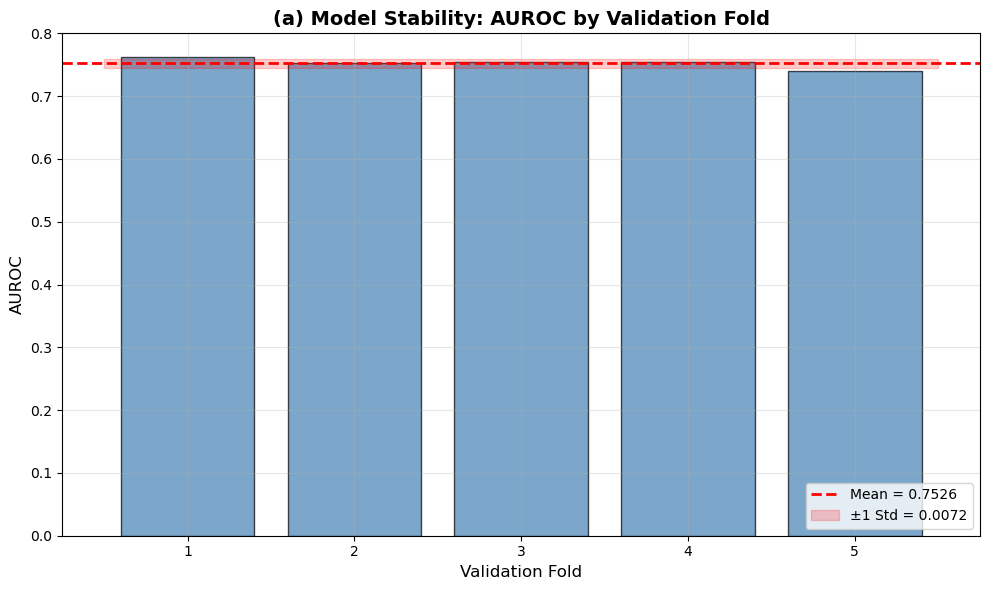


Getting feature importances...


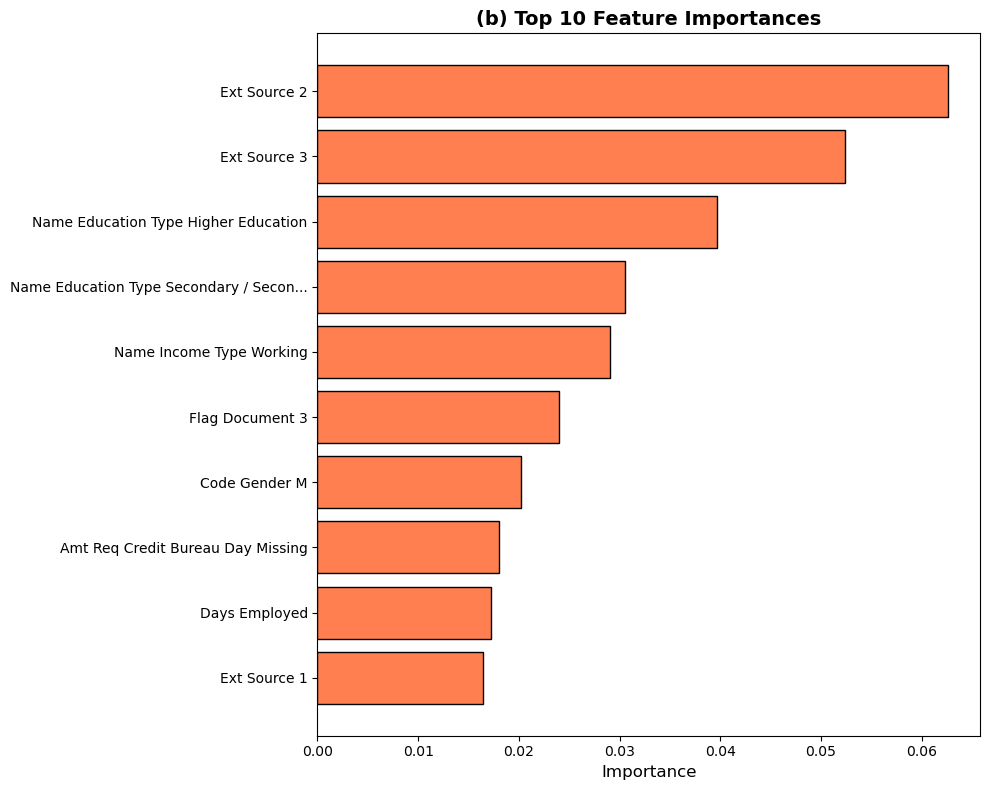


   Top feature: Ext Source 2 (0.0627)

Calculating Population Stability Index...


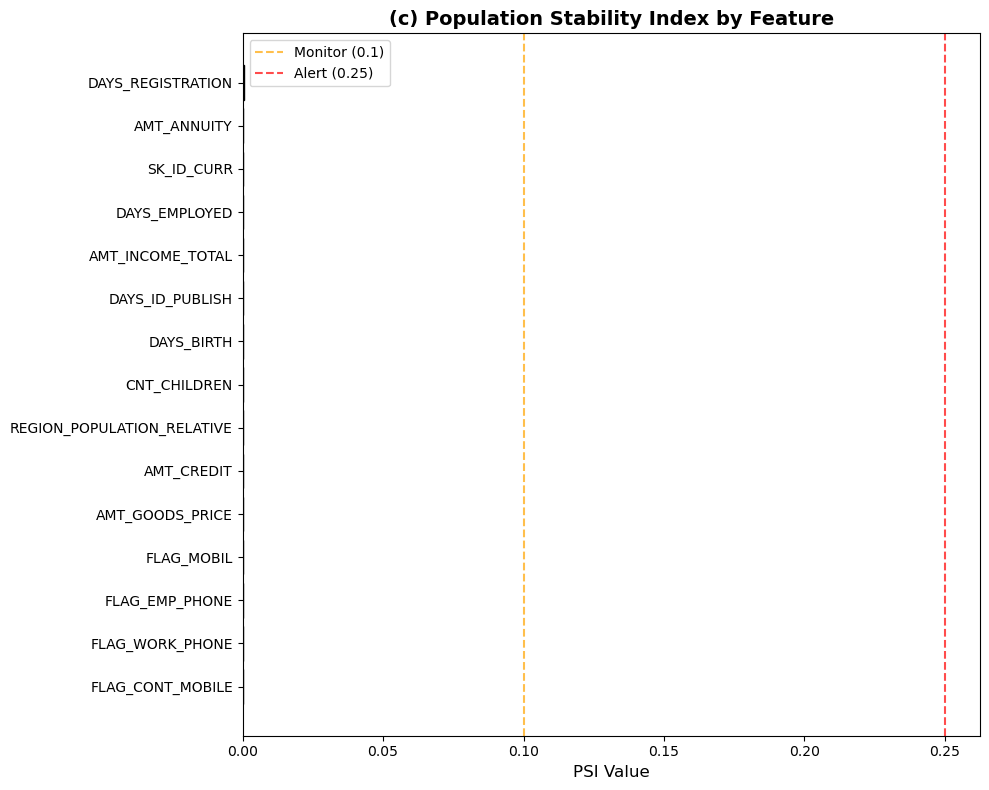


   PSI Summary:
   Stable (PSI < 0.1): 15
   Monitor (PSI 0.1-0.25): 0
   Alert (PSI > 0.25): 0


In [63]:
print("MODEL MONITORING DASHBOARD")

if 'X_test_processed' not in locals():
    if hasattr(best_pipeline, 'named_steps') and 'preprocessor' in best_pipeline.named_steps:
        preprocessor = best_pipeline.named_steps['preprocessor']
        X_test_processed = preprocessor.transform(X_test)
        if hasattr(preprocessor, 'get_feature_names_out'):
            feature_names = preprocessor.get_feature_names_out()
        else:
            feature_names = X_test.columns.tolist()
    else:
        X_test_processed = X_test
        feature_names = X_test.columns.tolist()


from sklearn.model_selection import cross_val_score, StratifiedKFold

if hasattr(best_pipeline, 'named_steps') and 'classifier' in best_pipeline.named_steps:
    base_model = best_pipeline.named_steps['classifier']
else:
    base_model = best_pipeline

if hasattr(best_pipeline, 'named_steps') and 'preprocessor' in best_pipeline.named_steps:
    model_for_cv = base_model
    X_for_cv = X_test_processed
else:
    model_for_cv = base_model
    X_for_cv = X_test

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_for_cv, X_for_cv, y_test, cv=cv, scoring='roc_auc')

cv_folds = list(range(1, len(cv_scores) + 1))
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print(f"   CV Scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"   Mean: {cv_mean:.4f} (±{cv_std:.4f})")

plt.figure(figsize=(10, 6))
plt.bar(cv_folds, cv_scores, color='steelblue', edgecolor='black', alpha=0.7)
plt.axhline(y=cv_mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {cv_mean:.4f}')
plt.fill_between([0.5, len(cv_scores) + 0.5], cv_mean - cv_std, cv_mean + cv_std, 
                  alpha=0.2, color='red', label=f'±1 Std = {cv_std:.4f}')
plt.xlabel('Validation Fold', fontsize=12)
plt.ylabel('AUROC', fontsize=12)
plt.title('(a) Model Stability: AUROC by Validation Fold', fontsize=14, fontweight='bold')
plt.xticks(cv_folds)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nGetting feature importances...")

if hasattr(base_model, 'feature_importances_'):
    importances = base_model.feature_importances_
    
    if 'feature_names' in locals():
        feature_names_all = feature_names
    else:
        feature_names_all = [f'feature_{i}' for i in range(len(importances))]
    
    importance_df = pd.DataFrame({
        'feature': feature_names_all[:len(importances)],
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_10 = importance_df.head(10)
    
    clean_names = []
    for name in top_10['feature'].values:
        clean = name.replace('num__', '').replace('cat__', '')
        clean = clean.replace('_', ' ').title()
        if len(clean) > 40:
            clean = clean[:37] + '...'
        clean_names.append(clean)
    
    plt.barh(range(len(top_10)), top_10['importance'].values, color='coral', edgecolor='black')
    plt.yticks(range(len(top_10)), clean_names)
    plt.xlabel('Importance', fontsize=12)
    plt.title('(b) Top 10 Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n   Top feature: {clean_names[0]} ({top_10.iloc[0]['importance']:.4f})")
else:
    print("   Feature importances not available")
    plt.figure(figsize=(10, 8))
    plt.text(0.5, 0.5, 'Feature importances not available', ha='center', va='center', fontsize=14)
    plt.title('(b) Top 10 Feature Importances', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("\nCalculating Population Stability Index...")

# Function to calculate PSI
def calc_psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    
    if len(expected) == 0 or len(actual) == 0:
        return 0
    
    try:
        expected_percentiles = np.percentile(expected, np.linspace(0, 100, bins+1))
        expected_percentiles = np.unique(expected_percentiles)
        
        expected_binned = np.digitize(expected, expected_percentiles[1:-1])
        actual_binned = np.digitize(actual, expected_percentiles[1:-1])
        
        expected_counts = np.bincount(expected_binned, minlength=len(expected_percentiles))
        actual_counts = np.bincount(actual_binned, minlength=len(expected_percentiles))
        
        expected_props = expected_counts / len(expected)
        actual_props = actual_counts / len(actual)
        
        expected_props = np.maximum(expected_props, 0.0001)
        actual_props = np.maximum(actual_props, 0.0001)
        
        return np.sum((actual_props - expected_props) * np.log(actual_props / expected_props))
    except:
        return 0

psi_results = []
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

for feat in numeric_cols[:15]:
    if feat in X_train.columns and feat in X_test.columns:
        train_vals = X_train[feat].dropna()
        test_vals = X_test[feat].dropna()
        
        if len(train_vals) > 0 and len(test_vals) > 0:
            psi_val = calc_psi(train_vals, test_vals)
            psi_results.append({'feature': feat, 'psi': psi_val})

if len(psi_results) > 0:
    psi_df = pd.DataFrame(psi_results).sort_values('psi', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 8))
    psi_vals = psi_df['psi'].values[:15]
    feature_names_psi = psi_df['feature'].values[:15]
    colors = ['red' if x > 0.25 else 'orange' if x > 0.1 else 'green' for x in psi_vals]
    
    plt.barh(range(len(psi_vals)), psi_vals, color=colors, edgecolor='black')
    plt.yticks(range(len(psi_vals)), feature_names_psi)
    plt.xlabel('PSI Value', fontsize=12)
    plt.title('(c) Population Stability Index by Feature', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    
    plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Monitor (0.1)')
    plt.axvline(x=0.25, color='red', linestyle='--', alpha=0.7, label='Alert (0.25)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"\n   PSI Summary:")
    print(f"   Stable (PSI < 0.1): {len([p for p in psi_vals if p < 0.1])}")
    print(f"   Monitor (PSI 0.1-0.25): {len([p for p in psi_vals if 0.1 <= p <= 0.25])}")
    print(f"   Alert (PSI > 0.25): {len([p for p in psi_vals if p > 0.25])}")
    
    if any(p > 0.25 for p in psi_vals):
        print("\n   WARNING: Features with PSI > 0.25 detected!")
        high_psi = psi_df[psi_df['psi'] > 0.25]
        for _, row in high_psi.iterrows():
            print(f"      • {row['feature']}: {row['psi']:.4f}")
else:
    print("   Could not calculate PSI")
